**Pneumonia Detection using Resnet Transfer Learning for vorhersage with LIME**

In [1]:
%%capture
!pip install lime

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Modell laden und Vorhersagefunktion für neue Bilder

In [3]:
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
save_path = '/content/drive/MyDrive/pneumonia_resnet101_best_model.pth'
class_names = ['NORMAL', 'PNEUMONIA']
data_dir = "/content/drive/MyDrive/chest_xray"
Image_path = "/content/drive/MyDrive/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

print(f"Lade Modell von: {save_path}")

# 1. Initialisieren Sie die Modellarchitektur (ResNet101)
# pretrained=False, da wir unsere eigenen trainierten Gewichte laden werden.
loaded_model = models.resnet101(pretrained=False)

# 2. Passen Sie die Klassifizierungsschicht an die im Training verwendete an.
# Die Anzahl der Eingabefeatures für die finale Schicht von ResNet101 ist 2048.
num_ftrs = loaded_model.fc.in_features
loaded_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, len(class_names)) # len(class_names) sollte 2 sein (NORMAL, PNEUMONIA)
).to(device)

# 3. Laden Sie die gespeicherten Gewichte (state_dict)
# map_location stellt sicher, dass es auf die richtige Hardware geladen wird (CPU oder GPU)
loaded_model.load_state_dict(torch.load(save_path, map_location=device))

# 4. Verschieben Sie das Modell auf das angegebene Gerät (CPU oder GPU)
loaded_model = loaded_model.to(device)

# 5. Setzen Sie das Modell in den Evaluierungsmodus
loaded_model.eval()

print("Trainiertes Modell von Drive geladen und zur Evaluierung bereit.")

# Define transformations for a single inference image
# These should be the same as the TEST phase transformations
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Define the prediction function
def predict_new_image(image_path, model, transform, class_names):
    """
    Lädt ein Bild, wendet Transformationen an und macht eine Vorhersage.

    Args:
        image_path (str): Der Pfad zum neuen Bild.
        model (torch.nn.Module): Das geladene Modell.
        transform (torchvision.transforms.Compose): Die Transformationen für das Bild.
        class_names (list): Eine Liste der Klassennamen.

    Returns:
        tuple: (predicted_class_name, confidence, all_probabilities_tensor, processed_image_tensor)
    """
    try:
        image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Fehler: Bild unter {image_path} nicht gefunden.")
        return None, None, None, None
    except Exception as e:
        print(f"Fehler beim Laden oder Verarbeiten des Bildes: {e}")
        return None, None, None, None

    input_tensor = transform(image)
    input_batch = input_tensor.unsqueeze(0)  # Fügen Sie eine Batch-Dimension hinzu

    input_batch = input_batch.to(device)

    with torch.no_grad():
        output = model(input_batch)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    _, predicted_idx = torch.max(output, 1)

    predicted_class_name = class_names[predicted_idx.item()]
    confidence = probabilities[predicted_idx.item()].item()

    return predicted_class_name, confidence, probabilities, input_tensor.cpu() # Gibt CPU-Tensor für die Anzeige zurück

print("Funktion zum Vorhersagen neuer Bilder definiert.")

Lade Modell von: /content/drive/MyDrive/pneumonia_resnet101_best_model.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Trainiertes Modell von Drive geladen und zur Evaluierung bereit.
Funktion zum Vorhersagen neuer Bilder definiert.


## Beispiel für die Verwendung der Vorhersagefunktion

Um die `predict_new_image`-Funktion zu verwenden, müssen Sie einen Pfad zu einem Bild angeben, das Sie testen möchten.

**Hinweis**: Sie können ein Bild aus Ihrem Google Drive wählen (z.B. `/content/drive/MyDrive/mein_bild.jpg`) oder ein Bild aus dem bereits geladenen Datensatz verwenden, um es als neues Bild zu simulieren. Hier ist ein Beispiel, das ein Bild aus Ihrem `TEST`-Datensatzpfad verwendet.

Verwende Beispielbild für die Vorhersage: /content/drive/MyDrive/chest_xray/test/NORMAL/IM-0001-0001.jpeg

Vorhergesagte Klasse: NORMAL
Konfidenz: 0.5499
Alle Wahrscheinlichkeiten: {'NORMAL': 0.5498815774917603, 'PNEUMONIA': 0.4501185119152069}


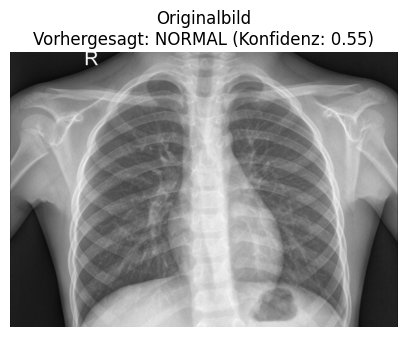

In [4]:
import matplotlib.pyplot as plt

# Beispiel: Finden Sie ein Bild im Test-Datensatzpfad
# Nehmen wir das erste PNEUMONIA-Bild, das wir finden können, als Beispiel
example_image_path = "/content/drive/MyDrive/chest_xray/test/NORMAL/IM-0001-0001.jpeg"
# for root, _, files in os.walk(os.path.join(data_dir, TEST, 'PNEUMONIA')):
#     if files:
#         example_image_path = os.path.join(root, files[0])
#         break

if example_image_path:
    print(f"Verwende Beispielbild für die Vorhersage: {example_image_path}")

    predicted_class, confidence, probs, processed_img_tensor = predict_new_image(
        example_image_path, loaded_model, inference_transform, class_names
    )

    if predicted_class:
        print(f"\nVorhergesagte Klasse: {predicted_class}")
        print(f"Konfidenz: {confidence:.4f}")
        print("Alle Wahrscheinlichkeiten:", {name: p.item() for name, p in zip(class_names, probs)})

        # Optional: Originalbild und Vorhersage anzeigen
        plt.figure(figsize=(5, 5))
        plt.imshow(Image.open(example_image_path).convert('RGB'))
        plt.title(f"Originalbild\nVorhergesagt: {predicted_class} (Konfidenz: {confidence:.2f})")
        plt.axis('off')
        plt.show()
    else:
        print("Vorhersage fehlgeschlagen.")
else:
    print("Kein Beispielbild im Test-Datensatz gefunden. Bitte geben Sie einen gültigen Pfad an.")

In [5]:
import torch.nn.functional as F

def predict_proba(images):
    # 1. Convert NumPy array images to PyTorch tensors and adjust shape.
    # LIME typically provides images as (batch_size, H, W, C) NumPy arrays.
    # PyTorch expects (batch_size, C, H, W).
    images_tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)

    # 2. Move the preprocessed tensors to the appropriate device.
    images_tensor = images_tensor.to(device)

    # 3. Normalize these PyTorch image tensors using the same mean and standard deviation
    # values used during the model's training. Convert numpy mean/std to torch tensors
    # and reshape for broadcasting.
    mean_t = torch.tensor(mean).to(images_tensor.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std).to(images_tensor.device).view(1, 3, 1, 1)

    # Apply normalization (assuming LIME provides images in [0, 1] range as floats)
    images_tensor = (images_tensor - mean_t) / std_t

    # 4. Set the model to evaluation mode.
    loaded_model.eval()

    # 5. Pass the preprocessed images through the model to get raw output logits.
    with torch.no_grad():
        outputs = loaded_model(images_tensor)

    # 6. Apply a softmax function to the logits to convert them into probabilities.
    probabilities = F.softmax(outputs, dim=1)

    # 7. Move the resulting probabilities back to the CPU and convert them to a NumPy array.
    return probabilities.cpu().numpy()

print("LIME-compatible predict_proba function defined.")

LIME-compatible predict_proba function defined.


In [6]:
from lime.lime_image import LimeImageExplainer
from PIL import Image
import numpy as np

# Define mean and std based on the inference_transform used in cell 98f53b2a
# These values are needed for un-normalization before passing to LIME
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Load the image from Image_path
try:
    image_for_lime = Image.open(Image_path).convert('RGB')
except FileNotFoundError:
    print(f"Fehler: Bild unter {Image_path} nicht gefunden.")
    raise # Re-raise to stop execution if image not found
except Exception as e:
    print(f"Fehler beim Laden oder Verarbeiten des Bildes für LIME: {e}")
    raise

# Apply the inference_transform to get a PyTorch tensor
# inference_transform is defined in cell 98f53b2a
input_tensor_for_lime = inference_transform(image_for_lime)

# Convert to NumPy array and transpose dimensions (C, H, W) to (H, W, C)
image_np_for_lime = input_tensor_for_lime.cpu().numpy().transpose((1, 2, 0))

# Un-normalize the image from the model's expected range to [0, 1] for LIME display
mean_np = np.array(mean)
std_np = np.array(std)
lime_image = std_np * image_np_for_lime + mean_np
lime_image = np.clip(lime_image, 0, 1) # Clip to ensure values are within [0, 1]

# Get prediction for true label if needed (for display, not for explainer itself)
# This part assumes predict_new_image was run and 'predicted_class' and 'class_names' are available
# If we want the true label, we need to know it from the dataset or define it manually
# For now, we will use the predicted label from the previous run for consistency in display.
# If the actual ground truth label is needed, it would come from dataset metadata.
predicted_idx_for_lime = class_names.index(predicted_class) # Assuming predicted_class is available from previous cell
true_label_lime = predicted_idx_for_lime # Using predicted as a placeholder for display label

print(f"Prepared image for LIME with shape: {lime_image.shape}")
print(f"Using predicted label '{class_names[true_label_lime]}' for LIME explanation.")

# Instantiate LimeImageExplainer
explainer = LimeImageExplainer()

# Get the explanation for the chosen image
explanation = explainer.explain_instance(
    image=lime_image, # Use the prepared lime_image
    classifier_fn=predict_proba,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

print("LIME explanation generated.")

Prepared image for LIME with shape: (224, 224, 3)
Using predicted label 'NORMAL' for LIME explanation.


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation generated.


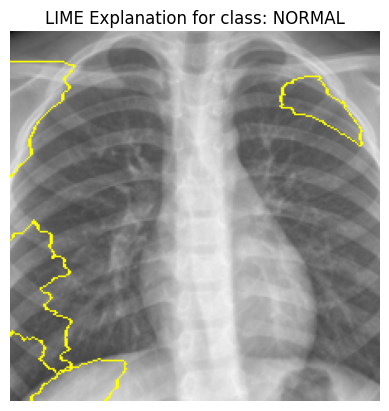

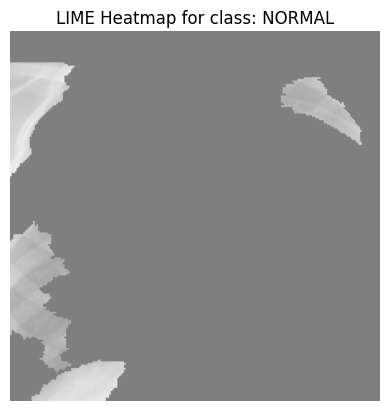

In [7]:
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Get the image and mask for the top label
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=True
)

# Display the original image with the LIME explanation overlay
plt.imshow(mark_boundaries(lime_image, mask))
plt.title(f'LIME Explanation for class: {class_names[explanation.top_labels[0]]}')
plt.axis('off')
plt.show()

# Optionally, display the heatmap for the explanation
plt.imshow(temp / 2 + 0.5) # Normalize to [0,1] for display
plt.title(f'LIME Heatmap for class: {class_names[explanation.top_labels[0]]}')
plt.axis('off')
plt.show()